# Empirical Closed-form Model (matches Voc,Isc,Vmp,Imp)

$I(V) = I_{sc} * [1-C_{1}e^{\frac{V}{C_{2}•V_{Oc}}}]$

$C₂ = (Vmp/Voc − 1) / ln(1 − Imp/Isc)$

$C₁ = (1 − I{mp}/I{sc}) · e^{(−V{mp} / (C₂·V{oc}))}$

This is the standard closed-form approximation in PV engineering. 

# Environmental Variation

Standard first order relations are:

$I_{sc}(G) = I_{sc,ref}*(G/G_{ref})$ 
Short circuit current scales linearly with irradiance

$V_{oc}(T) = V_{oc,ref} + \beta*(T-T_{ref})$
Open circuit voltage has a negtaive temperature coefficient $\beta$

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import math
from scipy.optimize import brentq

In [2]:
# Inputs
grid_resolution = 4096 # Tied to 12-bit ADC of ESP32 and similar models
# Assumed inputs
Voc = 21.5
Isc = 3.0
Vmp = 17.5
Imp = 2.7

V_grid = np.linspace(0,Voc,grid_resolution)


C2 = (Vmp/Voc-1)/math.log(1-Imp/Isc)
C1 = (1-Imp/Isc)*math.exp(-Vmp/(C2*Voc))
def I_pv(V):
    return Isc*(1-C1*(np.exp(V/(C2*Voc))-1))
I_grid = I_pv(V_grid)
P = V_grid*I_grid

# Ground-Truth MPP
idx = np.argmax(P)
V_mpp = V_grid[idx]
P_mpp = P[idx]
# Tests
print(I_grid[0])   # should be ≈ 3.0 (Isc)
print(I_grid[-1])  # should be ≈ 0 (at V = Voc)
print(V_mpp)  # should land close to 17.5 (Vmp)



3.0
1.2650895100163595e-05
17.33650793650794


Text(0.5, 1.0, 'Empirical Current-Voltage Curve')

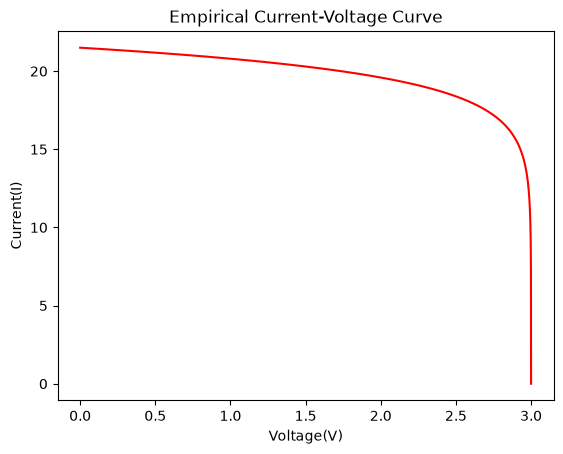

In [3]:
plt.plot(I_grid,V_grid,linestyle='solid',color='r')
plt.xlabel('Voltage(V)')
plt.ylabel('Current(I)')
plt.title("Empirical Current-Voltage Curve")

# Buck Converter Simulation

In [4]:
def buck_converter(R_load,D):
    R_in = (1/D**2)*R_load
    return R_in
R_load = 2.7 # Assumed from using R_load = R_mpp * D**2
D = 0.5
R_in = buck_converter(R_load,D)

def res(V,R_in):
    return I_pv(V) - V/R_in
V_intersection = brentq(res,a=1e-6,b=Voc,args = (R_in,))
I_intersection = I_pv(V_intersection)

# MPPT Algorithm Design

## IncCond

### Residual Function Solving

In [5]:
def res(V,R_in):
    return I_pv(V) - V/R_in
def brentqsolve(R_in,Voc):
    V_solution = brentq(res,a=1e-6,b=Voc,args = (R_in,))
    I_solution = I_pv(V_solution)
    return V_solution,I_solution

### Main Algorithm

In [6]:
N = 100 # Iterations
D = np.zeros(N)
D[0] = 0.5
V_traj = np.zeros(N)
I_traj = np.zeros(N)


def incCond(N,D,deltaD=5e-5,epsilon=1e-6,tolerance=1e-6):
    V_traj = np.zeros(N)
    I_traj = np.zeros(N)
    for i in range(N):
        R_in = buck_converter(R_load,D[i])
        V_traj[i],I_traj[i] = brentqsolve(R_in,Voc)
        if i == 0 and i+1 < N:
            D[i+1] = D[i] + deltaD  # forced pertubation
        elif i+1<N:
            D[i+1] = D[i]
        if i>0 and i+1<N:
            deltaV = V_traj[i] - V_traj[i-1]
            deltaI = I_traj[i] - I_traj[i-1]
            if np.abs(deltaV)<tolerance:
                if np.abs(deltaI)<tolerance:
                    pass
                elif deltaI >0:
                    D[i+1] +=deltaD
                else:
                    D[i+1] -= deltaD
            else:
                dI_dV = deltaI/deltaV
                target = -I_traj[i]/V_traj[i]
                if np.abs(dI_dV - target)<epsilon:
                    pass
                elif dI_dV<target:
                    D[i+1] += deltaD
                else:
                    D[i+1] -= deltaD
    return D, V_traj, I_traj

### How IncCond varies with number of iterations

For iterations(100), the saturation voltage is: 19.803611354800296
For iterations(1000), the saturation voltage is: 19.287564556546656
For iterations(1500), the saturation voltage is: 18.928160662414584
For iterations(3000), the saturation voltage is: 17.38253854534433
For iterations(3500), the saturation voltage is: 17.337544555270625
For iterations(5000), the saturation voltage is: 17.337544555270625


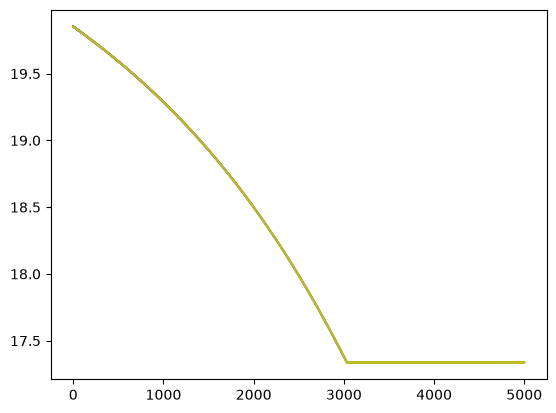

In [21]:
D = np.zeros(N)
D[0] = 0.5
_,V_iC_100,_ = incCond(100,D)
D = np.zeros(2000)
D[0] = 0.5
_,V_iC_200,_ = incCond(2000,D)
D = np.zeros(5000)
D[0] = 0.5
_,V_iC_300,_ = incCond(5000,D)

plt.plot(V_iC_100)
plt.plot(V_iC_200)
plt.plot(V_iC_300)

for i in [100,1000,1500,3000,3500,5000]:
    D = np.zeros(i)
    D[0] = 0.5
    _,V_current,_ = incCond(i,D)
    plt.plot(V_current)
    print("For iterations(" + str(i) + "), the saturation voltage is: " + str(V_current[-1]))


### Ideal number of iterations given constant deltaD

In [38]:
# Ideal convergence criteria(in terms of iterations given deltaD)
i = 0
tolerance_check = 0.02 # %
while 5>0:
    i+=100
    D = np.zeros(i)
    D[0] = 0.5
    _,V_current,_ = incCond(i,D)
    
    if np.abs(V_current[-1]-V_mpp)<tolerance_check*V_mpp:
        converged_itr = i
        print("Converged iteration: " + str(i))
        break
    



Converged iteration: 2800


### Point of convergence

In [41]:

D[0] = 0.5
_,V_converged,_ = incCond(converged_itr,D)
tolerance_check = 0.02  # 2%
converged_idx = np.argmax(np.abs(V_converged- V_mpp) < tolerance_check * V_mpp)
print(converged_idx)



2762


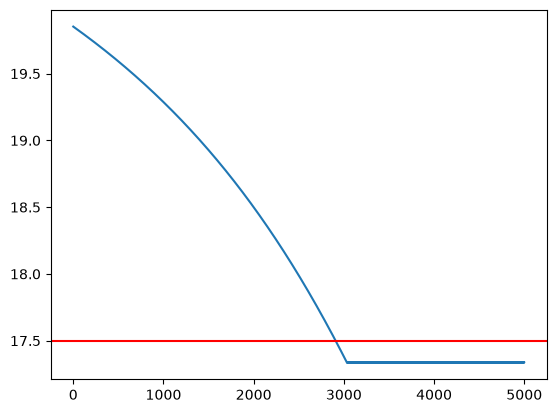

In [47]:
D = np.zeros(5000)
D[0] = 0.5
_,V_5000,_ = incCond(5000,D)
plt.plot(V_5000)
plt.axhline(Vmp, color = 'r', label = 'True MPP')


### Measuring Oscillation with respect to step-size

In [57]:
i = 0
for i in [5e-5,4e-5,2e-5,9e-4,5e-4,1e-4,1e-3,1e-2]:
    D = np.zeros(5000)
    D[0] = 0.5
    _,V,_ = incCond(5000,D,deltaD = i)
    print("Given deltaD: " + str(i)+ "; Standard deviation: "+ str(np.std(V[:-50])) + ";converging at " + str(V[-1]))
    




Given deltaD: 5e-05; Standard deviation: 0.910707533811891;converging at 17.337544555270625
Given deltaD: 4e-05; Standard deviation: 0.8846655382212479;converging at 17.337810603797653
Given deltaD: 2e-05; Standard deviation: 0.38281005868647155;converging at 18.500060402459116
Given deltaD: 0.0009; Standard deviation: 0.29905679293129966;converging at 17.325555515038324
Given deltaD: 0.0005; Standard deviation: 0.39499149454545224;converging at 17.341533572511107
Given deltaD: 0.0001; Standard deviation: 0.7861658066493045;converging at 17.33621406825421
Given deltaD: 0.001; Standard deviation: 0.2860505812587771;converging at 17.354803810461433
Given deltaD: 0.01; Standard deviation: 0.2074504280641862;converging at 17.381221925733122
